# 比亚迪A股 (002594.SZ) — 技术指标计算 Notebook

本 Notebook 演示四大经典技术指标的手动计算过程：

| 指标 | 中文名 | 用途 |
|:----|:------|:----|
| **RSI** | 相对强弱指标 | 判断超买/超卖 (14日) |
| **MACD** | 指数平滑异同平均线 | 趋势强度与方向 (12/26/9) |
| **Bollinger Bands** | 布林带 | 波动率与价格位置 (20, 2σ) |
| **ATR** | 平均真实波幅 | 市场波动性度量 (14日) |

> 数据：比亚迪A股 (002594.SZ) 过去一年日线，来源 Tushare Pro

---
## 0. 环境准备

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('✅ 环境就绪')

✅ 环境就绪


---
## 1. 数据获取

> 从 Tushare Pro 获取比亚迪A股 (002594.SZ) 日线数据。
> 港股数据返回的货币单位为 **人民币 (CNY)**。

In [2]:
# ========== 数据源配置 ==========
USE_CACHED = True   # True=读本地CSV, False=从API拉取
CSV_PATH = 'data/raw/002594.SZ_20250703_20260703.csv'
# ===============================

if USE_CACHED and os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
    print(f'✅ 从本地 CSV 读取: {len(df)} 条')

else:
    print('⚠️ 尝试从 Tushare MCP 拉取...')
    # 此处使用 Tushare MCP 接口或 Python SDK
    # 实际使用时可在下方填入 token 并取消注释
    # import tushare as ts
    # pro = ts.pro_api('your_token')
    # df = pro.daily(ts_code='002594.SZ', start_date='20250703', end_date='20260703')
    raise FileNotFoundError(f'请先确保 {CSV_PATH} 存在，或将 USE_CACHED 改为 False 并配置 Token')

df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df.sort_values('trade_date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'日期范围: {df["trade_date"].min().date()} ~ {df["trade_date"].max().date()}')
print(f'最新收盘价: ¥{df["close"].iloc[-1]:.2f}')
df[['trade_date', 'open', 'high', 'low', 'close', 'vol']].head()

✅ 从本地 CSV 读取: 243 条
日期范围: 2025-07-03 ~ 2026-07-03
最新收盘价: ¥88.47


,trade_date,open,high,low,close,vol
0,2025-07-03,330.98,335.25,330.67,334.56,123497.81
1,2025-07-04,332.55,334.99,329.77,331.00,104103.55
2,2025-07-07,329.20,330.49,328.44,328.59,88207.72
3,2025-07-08,327.00,329.78,325.72,326.88,116918.14
4,2025-07-09,326.90,328.21,325.78,325.80,121633.11


---
## 2. 数据基础诊断

在计算技术指标之前，先对原始数据进行质量检查和探索性分析。

检查项目包括：
- **缺失值检查** — 定位空数据
- **数据类型检查** — 确保字段类型正确
- **描述性统计** — 均值/标准差/极值/分位数
- **日期连续性** — 检测交易日间隔异常
- **异常值检测** — 3σ 原则识别极端值

In [8]:
print('='*50)
print('  数据基础诊断报告')
print('='*50)

# 1. 基本信息
print('📋 数据集基本信息')
print('  ├─ 行数: {len(df)}')
print('  ├─ 列数: {len(df.columns)}')
print('  ├─ 列名: {list(df.columns)}')
print('  ├─ 日期范围: {df["trade_date"].min().date()} ~ {df["trade_date"].max().date()}')
print('  └─ 交易日数: {len(df)}')

# 2. 缺失值检查
print('📊 缺失值检查')
missing = df.isnull().sum()
if missing.sum() > 0:
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({"缺失数量": missing, "缺失率(%)": missing_pct})
    print(missing_report[missing_report['缺失数量'] > 0].to_string())
else:
    print('  ✅ 无缺失值')

# 3. 数据类型检查
print('🔤 字段类型')
print(df.dtypes.to_string())

# 4. 描述性统计
print('📈 描述性统计 (数值字段)')
num_cols = ['open', 'high', 'low', 'close', 'vol', 'amount', 'pct_chg']
stats = df[num_cols].describe().round(2)
print(stats.to_string())

# 5. 日期连续性检查
print('📅 日期连续性检查')
date_diffs = df['trade_date'].diff().dropna()
max_gap = date_diffs.max()
print('  ├─ 最大间隔: {max_gap}')
if max_gap > pd.Timedelta(days=5):
    gap_mask = date_diffs > pd.Timedelta(days=5)
    print('  ├─ 超过 5 天的间隔数: {gap_mask.sum()}')
    gap_indices = df.index[1:][gap_mask]
    for idx in gap_indices[:3]:
        prev_date = df['trade_date'].iloc[idx-1].date()
        cur_date = df['trade_date'].iloc[idx].date()
        gap = date_diffs.iloc[idx-1]
        print('  │   {prev_date} -> {cur_date} (间隔 {gap})')
print('  └─ 最小日期: {df["trade_date"].min().date()}')
print('      最大日期: {df["trade_date"].max().date()}')

# 6. 关键指标快照
first_close = df['close'].iloc[0]
last_close = df['close'].iloc[-1]
total_return = (last_close / first_close - 1) * 100
up_days = (df['pct_chg'] > 0).sum()
down_days = (df['pct_chg'] < 0).sum()
flat_days = (df['pct_chg'] == 0).sum()

print('💰 关键指标')
print('  ├─ 起始收盘价: ¥{first_close:.2f}')
print('  ├─ 最新收盘价: ¥{last_close:.2f}')
print('  ├─ 期间涨跌幅: {total_return:+.2f}%')
print('  ├─ 最高价: ¥{df["high"].max():.2f}')
print('  ├─ 最低价: ¥{df["low"].min():.2f}')
print('  ├─ 均价: ¥{df["close"].mean():.2f}')
print('  ├─ 日收益率标准差: {df["pct_chg"].std():.2f}%')
print('  └─ 上涨天数: {up_days}  |  下跌天数: {down_days}  |  平盘天数: {flat_days}')

# 7. 异常值检查 (3σ 原则)
print('⚠️  异常值检查 (|z-score| > 3)')
for col in ['pct_chg', 'vol']:
    mean_v = df[col].mean()
    std_v = df[col].std()
    outlier_mask = (df[col] - mean_v).abs() > 3 * std_v
    print('  {col}: {outlier_mask.sum()} 个异常值')
    if outlier_mask.sum() > 0:
        for _, r in df[outlier_mask].head(3).iterrows():
            z = (r[col] - mean_v) / std_v
            print('    {r["trade_date"].date()}  {col}={r[col]:.2f}  (z={z:.2f})')

print('='*50)


  数据基础诊断报告
📋 数据集基本信息
  ├─ 行数: {len(df)}
  ├─ 列数: {len(df.columns)}
  ├─ 列名: {list(df.columns)}
  ├─ 日期范围: {df["trade_date"].min().date()} ~ {df["trade_date"].max().date()}
  └─ 交易日数: {len(df)}
📊 缺失值检查
  ✅ 无缺失值
🔤 字段类型
ts_code                  str
trade_date    datetime64[us]
open                 float64
high                 float64
low                  float64
close                float64
pre_close            float64
change               float64
pct_chg              float64
vol                  float64
amount               float64
📈 描述性统计 (数值字段)
         open    high     low   close         vol       amount  pct_chg
count  243.00  243.00  243.00  243.00      243.00       243.00   243.00
mean   116.00  117.41  114.83  116.09   460725.82   4871268.59    -0.07
std     60.95   61.47   60.61   61.12   242827.33   2468857.00     1.79
min     78.20   80.55   77.60   78.20    88207.72   1568057.39    -4.87
25%     94.86   95.82   94.02   94.78   307455.45   3251825.52    -1.19
50%     99.50  10

---
## 3. RSI — 相对强弱指标 (14日)

### 计算公式
1. 计算每日价格变动: `delta = close - close.shift(1)`
2. 分离上涨 (gain) 和下跌 (loss)
3. 用指数移动平均 (EMA) 平滑 gain 和 loss
4. `RS = avg_gain / avg_loss`
5. `RSI = 100 - 100 / (1 + RS)`

### 判断标准
- `RSI > 70`: 超买 (可能回调)
- `RSI < 30`: 超卖 (可能反弹)
- `RSI = 50`: 多空平衡

In [9]:
period = 14

# Step 1: 每日价格变动
delta = df['close'].diff()

# Step 2: 分离涨跌
gain = delta.where(delta > 0, 0.0)
loss = (-delta).where(delta < 0, 0.0)

# Step 3 & 4: 指数平滑平均
avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()

# Step 5 & 6: 计算 RSI
rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

# 检查最近的值
latest = df[['trade_date', 'close', 'rsi']].tail(5)
latest['rsi'] = latest['rsi'].round(1)
print('最近 5 个交易日的 RSI：')
print(latest.to_string(index=False))
print(f'\n📊 当前 RSI = {df["rsi"].iloc[-1]:.1f}')
if df['rsi'].iloc[-1] > 70:
    print('⚠️ 超买区域 (>70)')
elif df['rsi'].iloc[-1] < 30:
    print('⚠️ 超卖区域 (<30)')
else:
    print('✅ 正常区间')

最近 5 个交易日的 RSI：
trade_date  close  rsi
2026-06-29  79.64 25.7
2026-06-30  79.70 25.9
2026-07-01  80.66 29.6
2026-07-02  83.57 39.2
2026-07-03  88.47 51.4

📊 当前 RSI = 51.4
✅ 正常区间


---
## 4. MACD — 指数平滑异同移动平均线

### 计算公式
1. `EMA_fast = close.ewm(span=12).mean()`
2. `EMA_slow = close.ewm(span=26).mean()`
3. `DIF = EMA_fast - EMA_slow`
4. `DEA = DIF.ewm(span=9).mean()`
5. `MACD 柱 = DIF - DEA`

### 判断标准
- **金叉**: DIF 上穿 DEA → 买入信号
- **死叉**: DIF 下穿 DEA → 卖出信号
- **柱体 > 0**: 多头动能增强

In [10]:
fast, slow, signal = 12, 26, 9

# Step 1-2: 计算快慢 EMA
ema_fast = df['close'].ewm(span=fast, min_periods=fast).mean()
ema_slow = df['close'].ewm(span=slow, min_periods=slow).mean()

# Step 3: DIF
df['macd_dif'] = ema_fast - ema_slow

# Step 4: DEA (信号线)
df['macd_dea'] = df['macd_dif'].ewm(span=signal, min_periods=signal).mean()

# Step 5: MACD 柱
df['macd_hist'] = df['macd_dif'] - df['macd_dea']

# 判断最新信号
latest_dif = df['macd_dif'].iloc[-1]
latest_dea = df['macd_dea'].iloc[-1]
latest_hist = df['macd_hist'].iloc[-1]

print(f'最新 MACD 值：')
print(f'  DIF (快线):  {latest_dif:.3f}')
print(f'  DEA (信号线): {latest_dea:.3f}')
print(f'  MACD 柱:    {latest_hist:.3f}')

if latest_dif > latest_dea:
    print(f'  DIF 在 DEA 上方 → 多头优势')
else:
    print(f'  DIF 在 DEA 下方 → 空头优势')

# 金叉/死叉检测
prev_dif = df['macd_dif'].iloc[-2]
prev_dea = df['macd_dea'].iloc[-2]
if prev_dif < prev_dea and latest_dif > latest_dea:
    print('🔴 金叉信号！DIF 上穿 DEA')
elif prev_dif > prev_dea and latest_dif < latest_dea:
    print('🟢 死叉信号！DIF 下穿 DEA')

最新 MACD 值：
  DIF (快线):  -3.206
  DEA (信号线): -3.493
  MACD 柱:    0.287
  DIF 在 DEA 上方 → 多头优势
🔴 金叉信号！DIF 上穿 DEA


---
## 5. 布林带 (20日, 2 倍标准差)

### 计算公式
1. `中轨 = close.rolling(20).mean()`
2. `标准差 = close.rolling(20).std()`
3. `上轨 = 中轨 + 2 × 标准差`
4. `下轨 = 中轨 - 2 × 标准差`
5. `带宽 = (上轨 - 下轨) / 中轨 × 100%`
6. `%B = (收盘价 - 下轨) / (上轨 - 下轨)`

### 判断标准
- 价格接触/突破上轨 → 超买或强趋势
- 价格接触/跌破下轨 → 超卖或强趋势
- 带宽收窄 (Squeeze) → 即将突破
- `%B > 1`: 价格在上轨之上
- `%B < 0`: 价格在下轨之下

In [11]:
bb_period, bb_std = 20, 2

# Step 1-2: 计算中轨和标准差
df['boll_mid'] = df['close'].rolling(bb_period).mean()
bb_std_val = df['close'].rolling(bb_period).std()

# Step 3-4: 上下轨
df['boll_upper'] = df['boll_mid'] + bb_std * bb_std_val
df['boll_lower'] = df['boll_mid'] - bb_std * bb_std_val

# Step 5: 带宽
df['boll_bandwidth'] = (df['boll_upper'] - df['boll_lower']) / df['boll_mid'] * 100

# Step 6: %B
df['boll_pctb'] = (df['close'] - df['boll_lower']) / (df['boll_upper'] - df['boll_lower'])

# 最新值
last = df.iloc[-1]
print(f'最新布林带值：')
print(f'  上轨: ¥{last["boll_upper"]:.2f}')
print(f'  中轨: ¥{last["boll_mid"]:.2f}')
print(f'  下轨: ¥{last["boll_lower"]:.2f}')
print(f'  收盘价: ¥{last["close"]:.2f}')
print(f'  带宽: {last["boll_bandwidth"]:.2f}%')
print(f'  %B:  {last["boll_pctb"]:.3f}')

if last['close'] > last['boll_upper']:
    print('⚠️ 价格突破上轨！')
elif last['close'] < last['boll_lower']:
    print('⚠️ 价格跌破下轨！')
else:
    print('✅ 价格在布林带内部运行')

最新布林带值：
  上轨: ¥95.99
  中轨: ¥86.61
  下轨: ¥77.23
  收盘价: ¥88.47
  带宽: 21.65%
  %B:  0.599
✅ 价格在布林带内部运行


---
## 6. ATR — 平均真实波幅 (14日)

### 计算公式
1. `TR1 = high - low` (当日振幅)
2. `TR2 = |high - pre_close|` (最高到昨收)
3. `TR3 = |low - pre_close|` (最低到昨收)
4. `TR = max(TR1, TR2, TR3)` (真实波幅)
5. 首日 `ATR = TR.rolling(14).mean()`
6. 之后 `ATR = (前日 ATR × 13 + 当日 TR) / 14`

> ATR 越大 → 波动越大，适合缩小仓位、扩大止损

In [12]:
atr_period = 14

# Step 1-4: 计算 True Range
high_low = df['high'] - df['low']
high_pc = (df['high'] - df['pre_close']).abs()
low_pc = (df['low'] - df['pre_close']).abs()

df['true_range'] = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)

# Step 5-6: 计算 ATR (Wilder's Smoothed ATR)
df['atr'] = df['true_range'].rolling(atr_period).mean()

# 精度检查
last_tr = df['true_range'].iloc[-1]
last_atr = df['atr'].iloc[-1]

print(f'最新 ATR 值：')
print(f'  真实波幅 (TR):   ¥{last_tr:.3f}')
print(f'  平均真实波幅 (ATR): ¥{last_atr:.3f}')
print(f'  当前收盘价:        ¥{df["close"].iloc[-1]:.2f}')
print(f'  ATR / 收盘价:      {last_atr / df["close"].iloc[-1] * 100:.2f}%')

# 常用止损参考
entry_price = df['close'].iloc[-1]
print(f'\n📐 基于 ATR 的止损参考（2 倍 ATR）：')
print(f'  多头止损: ¥{entry_price - 2 * last_atr:.2f}')
print(f'  空头止损: ¥{entry_price + 2 * last_atr:.2f}')

最新 ATR 值：
  真实波幅 (TR):   ¥5.310
  平均真实波幅 (ATR): ¥3.089
  当前收盘价:        ¥88.47
  ATR / 收盘价:      3.49%

📐 基于 ATR 的止损参考（2 倍 ATR）：
  多头止损: ¥82.29
  空头止损: ¥94.65


---
## 7. 综合可视化

将四个指标绘制在同一张图上，便于综合判断。

findfont: Failed to find font weight bold, now using 600.


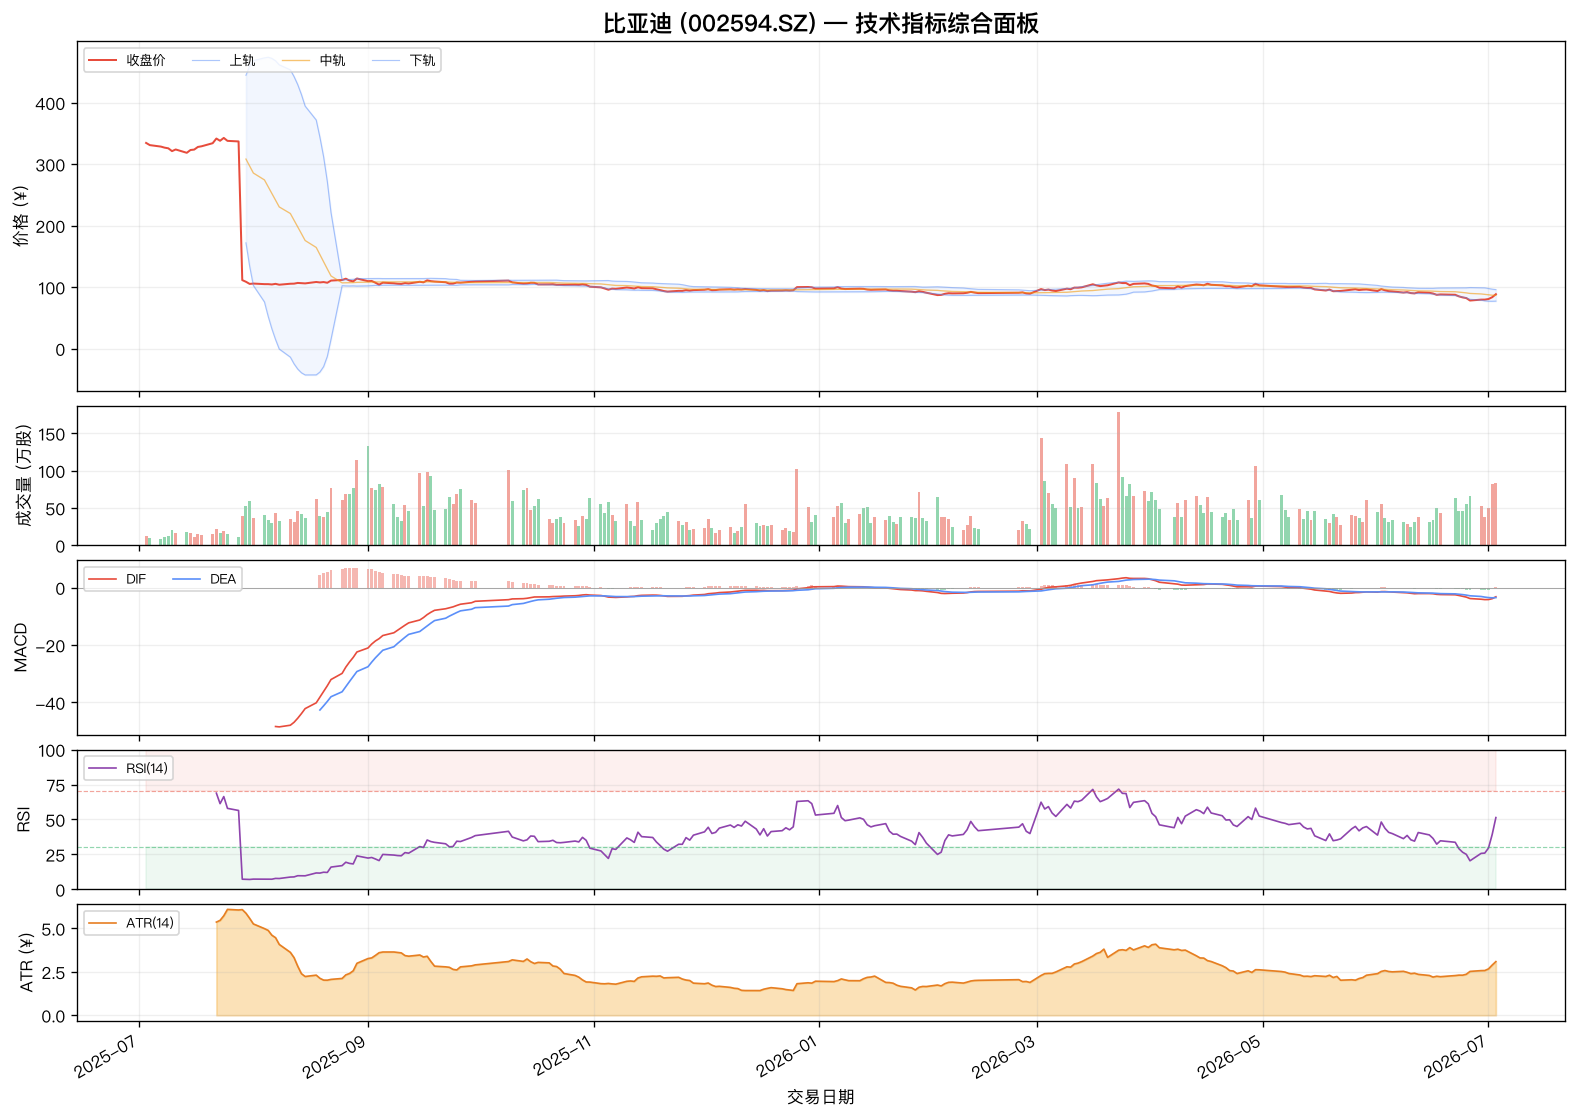

In [13]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(5, 1, height_ratios=[3, 1.2, 1.5, 1.2, 1], hspace=0.08)

dates = df['trade_date']

# ─── Panel 1: 价格 + 布林带 ───
ax1 = fig.add_subplot(gs[0])
ax1.plot(dates, df['close'], color='#e74c3c', linewidth=1.2, label='收盘价')
ax1.plot(dates, df['boll_upper'], color='#5b8ff9', linewidth=0.7, alpha=0.5, label='上轨')
ax1.plot(dates, df['boll_mid'], color='#f39c12', linewidth=0.8, alpha=0.6, label='中轨')
ax1.plot(dates, df['boll_lower'], color='#5b8ff9', linewidth=0.7, alpha=0.5, label='下轨')
ax1.fill_between(dates, df['boll_upper'], df['boll_lower'], alpha=0.08, color='#5b8ff9')
ax1.set_ylabel('价格 (¥)', fontsize=10)
ax1.set_title('比亚迪 (002594.SZ) — 技术指标综合面板', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, ncol=4)
ax1.grid(True, alpha=0.2)

# ─── Panel 2: 成交量 ───
ax2 = fig.add_subplot(gs[1], sharex=ax1)
colors = ['#e74c3c' if df['pct_chg'].iloc[i] >= 0 else '#27ae60' for i in range(len(df))]
ax2.bar(dates, df['vol'] / 10000, color=colors, alpha=0.5, width=0.8)
ax2.set_ylabel('成交量 (万股)', fontsize=10)
ax2.grid(True, alpha=0.2)

# ─── Panel 3: MACD ───
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(dates, df['macd_dif'], color='#e74c3c', linewidth=1, label='DIF')
ax3.plot(dates, df['macd_dea'], color='#5b8ff9', linewidth=1, label='DEA')
hist_colors = ['#e74c3c' if v >= 0 else '#27ae60' for v in df['macd_hist']]
ax3.bar(dates, df['macd_hist'], color=hist_colors, alpha=0.4, width=0.8)
ax3.axhline(y=0, color='#999', linewidth=0.5)
ax3.set_ylabel('MACD', fontsize=10)
ax3.legend(loc='upper left', fontsize=8, ncol=3)
ax3.grid(True, alpha=0.2)

# ─── Panel 4: RSI ───
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.plot(dates, df['rsi'], color='#8e44ad', linewidth=1, label='RSI(14)')
ax4.axhline(y=70, color='#e74c3c', linestyle='--', linewidth=0.7, alpha=0.5)
ax4.axhline(y=30, color='#27ae60', linestyle='--', linewidth=0.7, alpha=0.5)
ax4.fill_between(dates, 70, 100, alpha=0.08, color='#e74c3c')
ax4.fill_between(dates, 0, 30, alpha=0.08, color='#27ae60')
ax4.set_ylabel('RSI', fontsize=10)
ax4.set_ylim(0, 100)
ax4.legend(loc='upper left', fontsize=8)
ax4.grid(True, alpha=0.2)

# ─── Panel 5: ATR ───
ax5 = fig.add_subplot(gs[4], sharex=ax1)
ax5.fill_between(dates, df['atr'], alpha=0.3, color='#f39c12')
ax5.plot(dates, df['atr'], color='#e67e22', linewidth=1, label='ATR(14)')
ax5.set_ylabel('ATR (¥)', fontsize=10)
ax5.set_xlabel('交易日期', fontsize=10)
ax5.legend(loc='upper left', fontsize=8)
ax5.grid(True, alpha=0.2)

for ax in [ax1, ax2, ax3, ax4]:
    plt.setp(ax.xaxis.get_majorticklabels(), visible=False)

ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.show()
plt.close('all')

---
## 8. 综合信号汇总

整合四个指标的当前信号，方便快速判断。

In [14]:
last = df.iloc[-1]

# RSI 信号
rsi_signal = '超买' if last['rsi'] > 70 else ('超卖' if last['rsi'] < 30 else '中性')

# MACD 信号
if last['macd_dif'] > last['macd_dea']:
    macd_trend = '多头'
else:
    macd_trend = '空头'

# 布林带信号
if last['close'] > last['boll_upper']:
    boll_signal = '突破上轨'
elif last['close'] < last['boll_lower']:
    boll_signal = '跌破下轨'
else:
    boll_signal = '带内运行'

# ATR 波动率
atr_ratio = last['atr'] / last['close'] * 100
volatility = '高波动' if atr_ratio > 5 else ('低波动' if atr_ratio < 2 else '中等波动')

print(f'{"="*42}')
print(f'  比亚迪 (002594.SZ) — 技术指标信号汇总')
print(f'{"="*42}')
print(f'  日期:          {last["trade_date"].date()}')
print(f'  收盘价:        ¥{last["close"]:.2f}')
print(f'{"─"*42}')
print(f'  RSI({14:>2d}):        {last["rsi"]:.1f}  → {rsi_signal}')
print(f'  MACD DIF:      {last["macd_dif"]:.3f}  → {macd_trend}')
print(f'  MACD DEA:      {last["macd_dea"]:.3f}')
print(f'  布林带:        {boll_signal}')
print(f'  带宽:          {last["boll_bandwidth"]:.2f}%')
print(f'  ATR:           ¥{last["atr"]:.3f} ({volatility})')
print(f'  ATR/收盘价:    {atr_ratio:.2f}%')
print(f'{"─"*42}')
print(f'  💡 2倍ATR多头止损: ¥{last["close"] - 2 * last["atr"]:.2f}')
print(f'{"="*42}')
print('* 以上信号仅供参考，不构成投资建议 *')

  比亚迪 (002594.SZ) — 技术指标信号汇总
  日期:          2026-07-03
  收盘价:        ¥88.47
──────────────────────────────────────────
  RSI(14):        51.4  → 中性
  MACD DIF:      -3.206  → 多头
  MACD DEA:      -3.493
  布林带:        带内运行
  带宽:          21.65%
  ATR:           ¥3.089 (中等波动)
  ATR/收盘价:    3.49%
──────────────────────────────────────────
  💡 2倍ATR多头止损: ¥82.29
* 以上信号仅供参考，不构成投资建议 *


---
**数据来源**: [Tushare Pro](https://tushare.pro)  |  **指标规范**: `indicators_spec.yaml`

**声明**: 本 Notebook 仅演示技术指标的计算方法，不构成任何投资建议。